# Notebook 04 - Escalamiento y PCA

En este notebook se aplica escalamiento y reducción de dimensionalidad
mediante Análisis de Componentes Principales (PCA) sobre las variables
numéricas del dataset limpio. Se documentan las variables utilizadas,
el escalamiento aplicado, la varianza explicada y la interpretación
de cada componente obtenida.

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargamos el dataset limpio
df = pd.read_csv('../data/processed/streaming_users_clean.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 5886 filas, 8 columnas


## Selección de variables y justificación

Para el PCA se seleccionan las tres variables numéricas continuas del dataset:
- `age`: edad del usuario
- `monthly_watch_time_mins`: tiempo mensual de visualización en minutos
- `customer_support_tickets`: cantidad de tickets de soporte generados

Estas variables se eligieron porque no presentan correlaciones fuertes entre sí
(evidenciado en el mapa de calor del EDA), lo que las hace aptas para PCA.
Las variables categóricas como país, género y plan de suscripción se excluyen
porque PCA requiere variables numéricas.

In [2]:
# Seleccionamos las variables numéricas para el PCA
variables = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[variables]

print("Variables seleccionadas:")
print(X.describe().round(2))

Variables seleccionadas:
           age  monthly_watch_time_mins  customer_support_tickets
count  5886.00                  5886.00                   5886.00
mean     33.49                   863.85                      0.74
std      11.76                  1876.38                      0.87
min       0.00                     0.00                      0.00
25%      25.00                   502.95                      0.00
50%      33.00                   760.80                      1.00
75%      42.00                  1040.62                      1.00
max      80.00                 50000.00                      5.00


## Escalamiento

Antes de aplicar PCA es obligatorio escalar las variables. Sin escalamiento,
la variable con mayor varianza dominaría los componentes sin ninguna razón
válida. Se aplica estandarización Z-score (StandardScaler) que centra cada
variable en 0 y la lleva a varianza 1, preservando la distribución original.

In [3]:
# Aplicamos estandarización Z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificamos que todas las variables quedaron con varianza 1
X_scaled_df = pd.DataFrame(X_scaled, columns=variables)
print("Varianza antes del escalamiento:")
print(X.var().round(4))
print()
print("Varianza después del escalamiento:")
print(X_scaled_df.var().round(4))

Varianza antes del escalamiento:
age                         1.382507e+02
monthly_watch_time_mins     3.520809e+06
customer_support_tickets    7.483000e-01
dtype: float64

Varianza después del escalamiento:
age                         1.0002
monthly_watch_time_mins     1.0002
customer_support_tickets    1.0002
dtype: float64


## Aplicación de PCA

In [4]:
# Aplicamos PCA con todas las componentes posibles (3 variables = 3 componentes)
pca = PCA(n_components=3)
pca.fit(X_scaled)

# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = varianza_explicada.cumsum()

print("Varianza explicada por componente:")
for i, (v, va) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"  PC{i+1}: {v*100:.1f}% | Acumulada: {va*100:.1f}%")

Varianza explicada por componente:
  PC1: 33.7% | Acumulada: 33.7%
  PC2: 33.2% | Acumulada: 67.0%
  PC3: 33.0% | Acumulada: 100.0%


### Visualización 1 - Varianza explicada acumulada

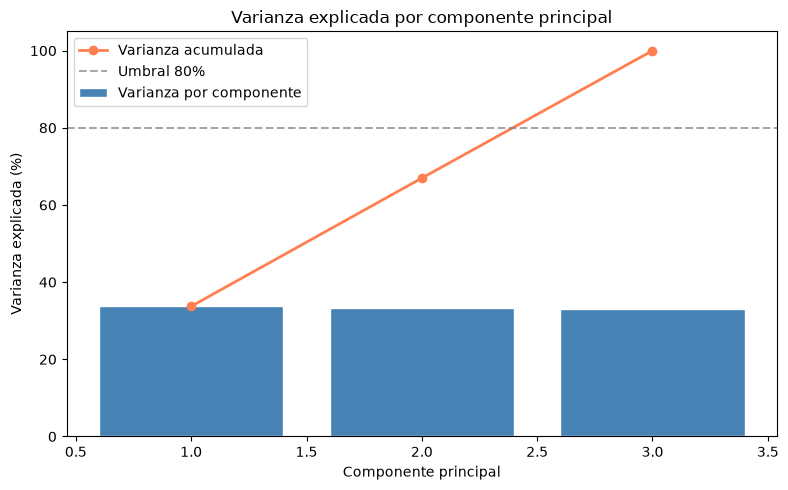

In [5]:
# Gráfico de varianza explicada acumulada
plt.figure(figsize=(8, 5))
plt.bar(range(1, 4), varianza_explicada * 100, color='steelblue',
        edgecolor='white', label='Varianza por componente')
plt.plot(range(1, 4), varianza_acumulada * 100, 'o-',
         color='coral', linewidth=2, label='Varianza acumulada')
plt.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='Umbral 80%')
plt.xlabel('Componente principal')
plt.ylabel('Varianza explicada (%)')
plt.title('Varianza explicada por componente principal')
plt.legend()
plt.tight_layout()
plt.show()

### Visualización 2 - Proyección de usuarios en las dos primeras componentes

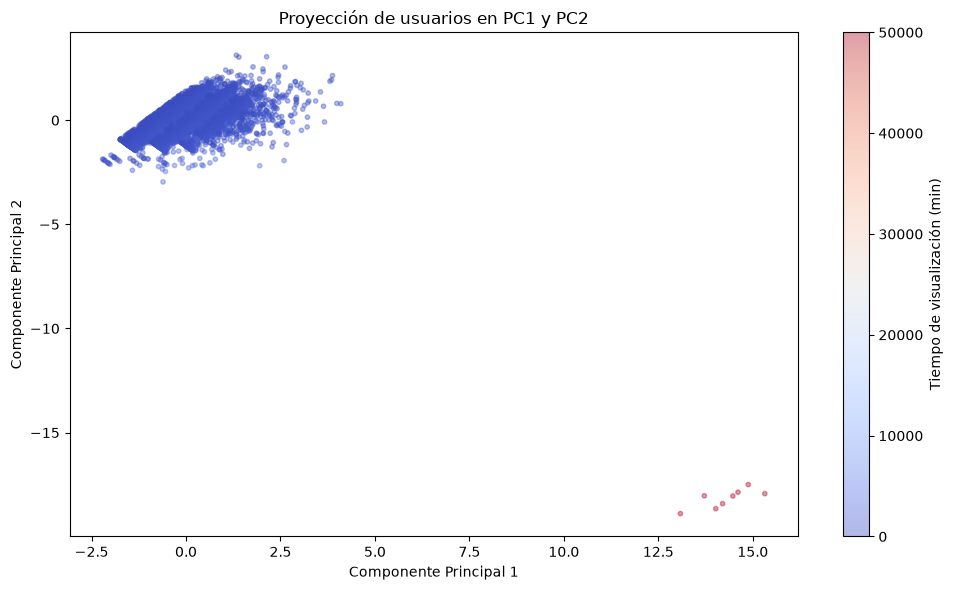

In [6]:
# Proyectamos los datos en las dos primeras componentes
X_pca = pca.transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['monthly_watch_time_mins'],
                      cmap='coolwarm', alpha=0.4, s=10)
plt.colorbar(scatter, label='Tiempo de visualización (min)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección de usuarios en PC1 y PC2')
plt.tight_layout()
plt.show()

## Interpretación de las componentes

La siguiente tabla muestra cuánto aporta cada variable original
a cada componente principal (loadings).

In [7]:
# Mostramos los loadings: contribución de cada variable a cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=variables,
    columns=['PC1', 'PC2', 'PC3']
).round(3)

print("Loadings (contribución de cada variable a cada componente):")
print(loadings)

Loadings (contribución de cada variable a cada componente):
                            PC1    PC2    PC3
age                       0.532  0.717 -0.451
monthly_watch_time_mins   0.539 -0.697 -0.473
customer_support_tickets  0.653 -0.008  0.757


## Interpretación general

El PCA sobre las tres variables numéricas muestra una distribución
de varianza muy uniforme entre los tres componentes: PC1 explica el 33.7%,
PC2 el 33.2% y PC3 el 33.0%. Esto indica que ninguna componente captura
una proporción dominante de la varianza, lo cual es coherente con las
bajas correlaciones observadas entre las variables en el EDA.

Analizando los loadings:
- **PC1** combina de forma similar las tres variables, con mayor peso en
  `customer_support_tickets` (0.653). Representa un perfil general del usuario
  que integra edad, consumo y nivel de incidencias.
- **PC2** opone `age` (0.717) contra `monthly_watch_time_mins` (-0.697),
  capturando la diferencia entre usuarios mayores con menor tiempo de consumo
  y usuarios jóvenes con mayor tiempo de consumo.
- **PC3** opone `customer_support_tickets` (0.757) contra las otras dos
  variables, representando el nivel de incidencias técnicas de forma aislada.

Para conservar el 80% de la varianza acumulada se necesitan las tres
componentes, lo que confirma que las tres variables originales aportan
información independiente y no redundante al dataset.